In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_parquet("./results/sivae_metrics.parquet").set_index("file_i")
df

Calculate the relative angle between the two points on the circular line between [-1, 1].

$$\Delta \theta = \text{atan2}(\sin(\pi(\hat{\delta} - \delta)), \cos(\pi(\hat{\delta} - \delta)))$$

The distance is maximal at $\delta - \hat{\delta} = 1$, and minimal at $\delta - \hat{\delta} = 0$, and is bounded between -1 and 1, so -1 and 1 are treated as the same.

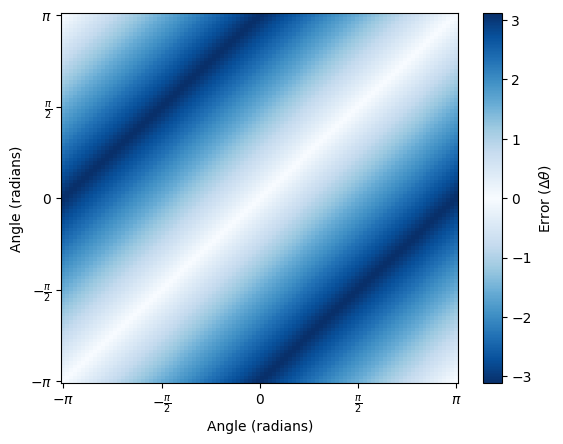

In [22]:
from matplotlib import colors as mcolors

def symmetrical_colormap(cmap_settings, new_name = None):
    cmap = plt.get_cmap(*cmap_settings)
    new_name = "sym_" + cmap_settings[0]  # ex: 'sym_Blues'
    n= 128 
    colors_r = cmap(np.linspace(0, 1, n))    # take the standard colormap # 'right-part'
    colors_l = colors_r[::-1]                # take the first list of color and flip the order # "left-part"
    colors = np.vstack((colors_l, colors_r))
    cmap = mcolors.LinearSegmentedColormap.from_list(new_name, colors)
    return cmap

theta_1, theta_2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-np.pi, np.pi, 100))
phi = (theta_1 - theta_2)
delta_theta = np.arctan2(np.sin(phi), np.cos(phi))
plt.pcolormesh(theta_1, theta_2, delta_theta, cmap=symmetrical_colormap(('Blues', None)))
cbar = plt.colorbar()
cbar.set_label(r"Error ($\Delta \theta$)")
plt.xlabel(r"Angle (radians)")
plt.ylabel(r"Angle (radians)")
plt.xticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
plt.yticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
plt.show()

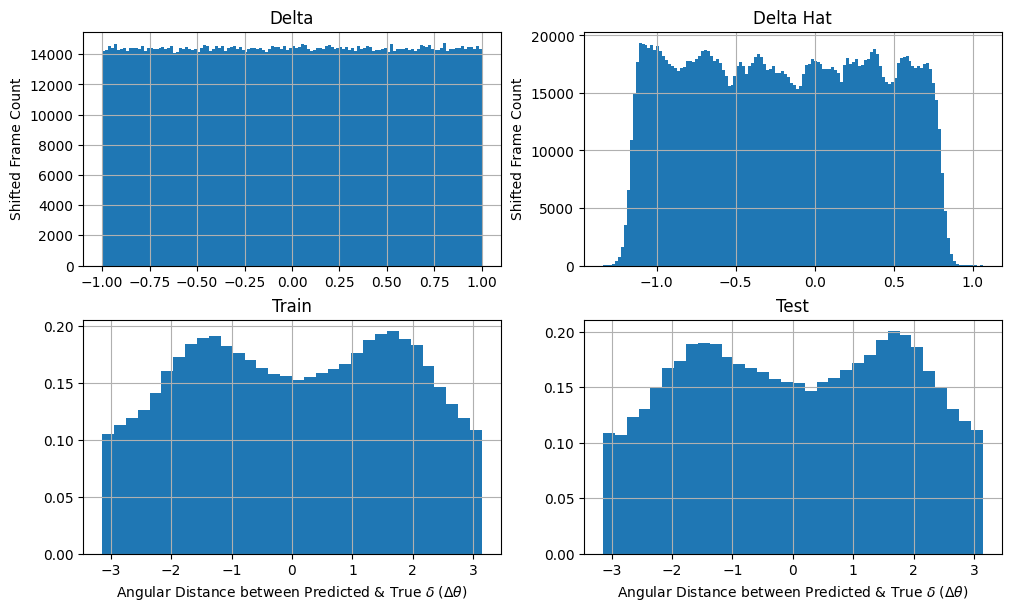

In [11]:
d = df["delta"]
dh = df["delta_hat"]
diff = np.pi * (d - dh)
err = np.arctan2(np.sin(diff), np.cos(diff))
df["angular_distance"] = err
df["angular_err"] = np.abs(err)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), constrained_layout=True)
df["delta"].hist(bins=128, ax=ax1)
df["delta_hat"].hist(bins=128, ax=ax2)
ax1.set_title("Delta")
ax2.set_title("Delta Hat")
df.loc[(df["stage"] == "train") | (df["stage"] == "val"), "angular_distance"].hist(bins=32, ax=ax3, density=True)
ax3.set_title("Train")
ax3.set_xlabel(r"Angular Distance ($\Delta \theta$)")
ax1.set_ylabel("Shifted Frame Count")
ax2.set_ylabel("Shifted Frame Count")
df.loc[(df["stage"] == "test"), "angular_distance"].hist(bins=32, ax=ax4, density=True)
ax4.set_title("Test")
ax3.set_xlabel(r"Angular Distance between Predicted & True $\delta$ ($\Delta \theta$)")
ax4.set_xlabel(r"Angular Distance between Predicted & True $\delta$ ($\Delta \theta$)")
plt.show()

In [6]:
def circular_mean_offset(y, y_hat, axis: int = -1):
    diff = y - y_hat
    sin_sum = np.mean(np.sin(diff), axis=axis)
    cos_sum = np.mean(np.cos(diff), axis=axis)
    offset = np.arctan2(sin_sum, cos_sum)
    y_hat_aligned = y_hat + offset
    return y_hat_aligned, offset

In [7]:
d = df["delta"].to_numpy().reshape(-1, 39, 10)
dh = df["delta_hat"].to_numpy().reshape(-1, 39, 10)
diff = np.pi * (d - dh)
sin_sum = np.mean(np.sin(diff), axis=-1)
cos_sum = np.mean(np.cos(diff), axis=-1)
offset = np.arctan2(sin_sum, cos_sum)
dha = dh + offset.reshape(-1, 39, 1)
df["delta_hat_aligned"] = dha.reshape(-1)

In [8]:
d = df["delta"]
dh = df["delta_hat_aligned"]
diff = np.pi * (d - dh)
err = np.arctan2(np.sin(diff), np.cos(diff))
df["angular_distance_aligned"] = err
df["angular_err_aligned"] = np.abs(err)

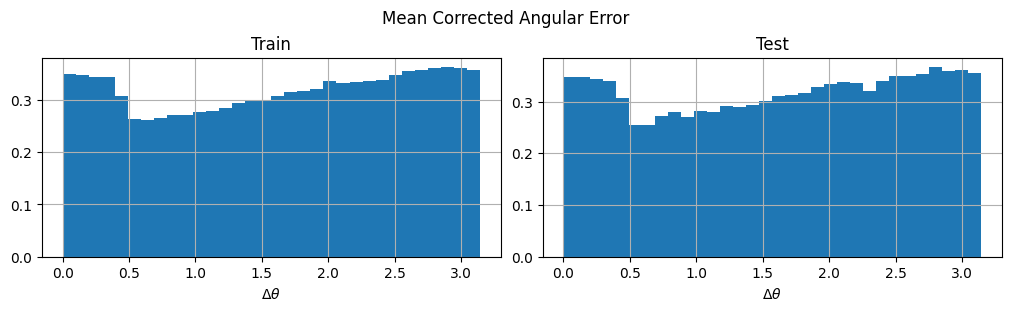

In [16]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), constrained_layout=True)
df.loc[(df["stage"] == "train") | (df["stage"] == "val"), "angular_err_aligned"].hist(bins=32, ax=ax1, density=True)
ax1.set_title("Train")
ax1.set_xlabel(r"$\Delta \theta$")

df.loc[(df["stage"] == "test"), "angular_err_aligned"].hist(bins=32, ax=ax2, density=True)
ax2.set_title("Test")
ax2.set_xlabel(r"$\Delta \theta$")

fig.suptitle("Mean Corrected Angular Error")
plt.show()

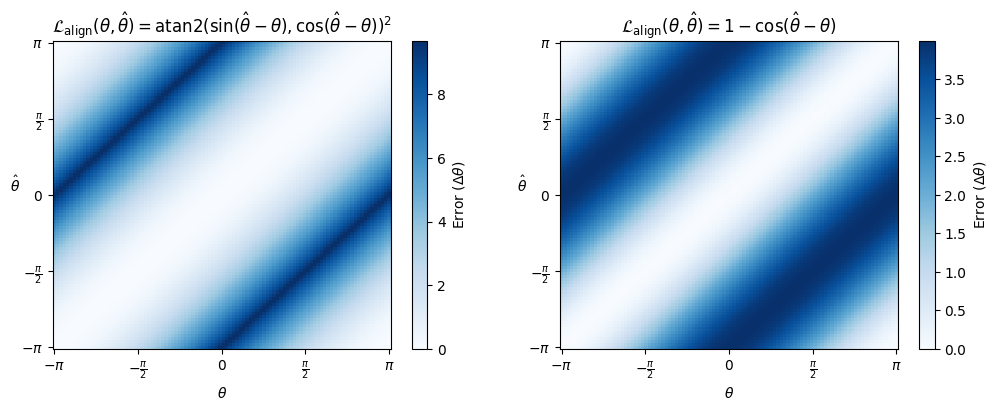

In [5]:
from matplotlib import colors as mcolors

def symmetrical_colormap(cmap_settings, new_name = None):
    cmap = plt.get_cmap(*cmap_settings)
    new_name = "sym_" + cmap_settings[0]  # ex: 'sym_Blues'
    n= 128 
    colors_r = cmap(np.linspace(0, 1, n))    # take the standard colormap # 'right-part'
    colors_l = colors_r[::-1]                # take the first list of color and flip the order # "left-part"
    colors = np.vstack((colors_l, colors_r))
    cmap = mcolors.LinearSegmentedColormap.from_list(new_name, colors)
    return cmap

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))
theta_1, theta_2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-np.pi, np.pi, 100))
phi = (theta_1 - theta_2)

delta_theta = np.arctan2(np.sin(phi), np.cos(phi))**2
mesh = ax1.pcolormesh(theta_1, theta_2, delta_theta, cmap="Blues")
cbar = fig.colorbar(mesh, ax=ax1, orientation="vertical")
cbar.set_label(r"Error ($\Delta \theta$)")
ax1.set_xlabel(r"$\theta$")
ax1.set_ylabel(r"$\hat{\theta}$", rotation=0)
ax1.set_xticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax1.set_yticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax1.set_title(r"$\mathcal{L}_{\text{align}}(\theta, \hat{\theta}) = \text{atan2}(\sin(\hat{\theta} - \theta), \cos(\hat{\theta} - \theta))^2$")

delta_theta = 2*(1 - np.cos(phi))
mesh = ax2.pcolormesh(theta_1, theta_2, delta_theta, cmap="Blues")
cbar = fig.colorbar(mesh, ax=ax2, orientation="vertical")
cbar.set_label(r"Error ($\Delta \theta$)")
ax2.set_xlabel(r"$\theta$")
ax2.set_ylabel(r"$\hat{\theta}$", rotation=0)
ax2.set_xticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax2.set_yticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax2.set_title(r"$\mathcal{L}_{\text{align}}(\theta, \hat{\theta}) = 1 - \cos(\hat{\theta} - \theta)$")

plt.show()

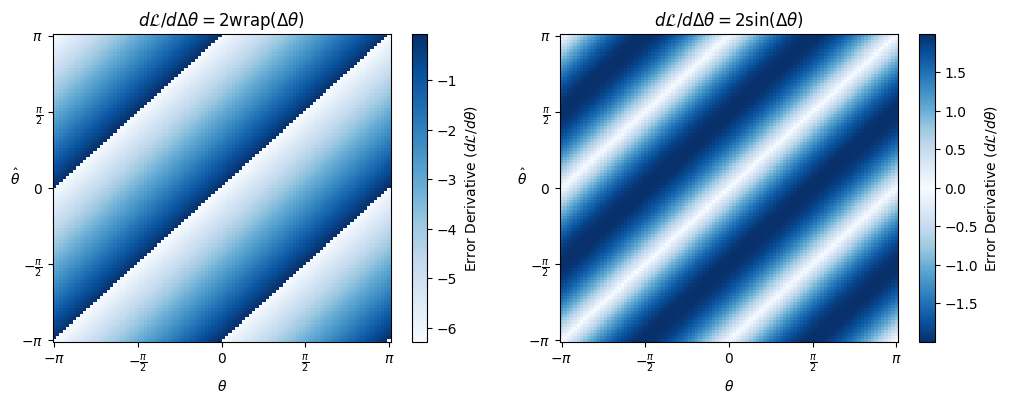

In [9]:
from matplotlib import colors as mcolors

def symmetrical_colormap(cmap_settings, new_name = None):
    cmap = plt.get_cmap(*cmap_settings)
    new_name = "sym_" + cmap_settings[0]  # ex: 'sym_Blues'
    n= 128 
    colors_r = cmap(np.linspace(0, 1, n))    # take the standard colormap # 'right-part'
    colors_l = colors_r[::-1]                # take the first list of color and flip the order # "left-part"
    colors = np.vstack((colors_l, colors_r))
    cmap = mcolors.LinearSegmentedColormap.from_list(new_name, colors)
    return cmap

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))
theta_1, theta_2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-np.pi, np.pi, 100))
phi = (theta_1 - theta_2)

delta_theta = 2*(((phi + np.pi) % np.pi) - np.pi)
mesh = ax1.pcolormesh(theta_1, theta_2, delta_theta, cmap="Blues")
cbar = fig.colorbar(mesh, ax=ax1, orientation="vertical")
cbar.set_label(r"Error Derivative ($d\mathcal{L}/d\theta$)")
ax1.set_xlabel(r"$\theta$")
ax1.set_ylabel(r"$\hat{\theta}$", rotation=0)
ax1.set_xticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax1.set_yticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax1.set_title(r"$d\mathcal{L}/d\Delta\theta = 2\text{wrap}(\Delta\theta)$")

delta_theta = 2*np.sin(phi)
mesh = ax2.pcolormesh(theta_1, theta_2, delta_theta, cmap=symmetrical_colormap(('Blues', None)))
cbar = fig.colorbar(mesh, ax=ax2, orientation="vertical")
cbar.set_label(r"Error Derivative ($d\mathcal{L}/d\theta$)")
ax2.set_xlabel(r"$\theta$")
ax2.set_ylabel(r"$\hat{\theta}$", rotation=0)
ax2.set_xticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax2.set_yticks(np.linspace(-np.pi, np.pi, 5), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'])
ax2.set_title(r"$d\mathcal{L}/d\Delta\theta = 2\sin(\Delta\theta)$")

plt.show()